In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from google.colab import files

In [ ]:
uploaded=files.upload()

df=pd.read_csv("heart.csv")
df.head(10)

Saving heart.csv to heart.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


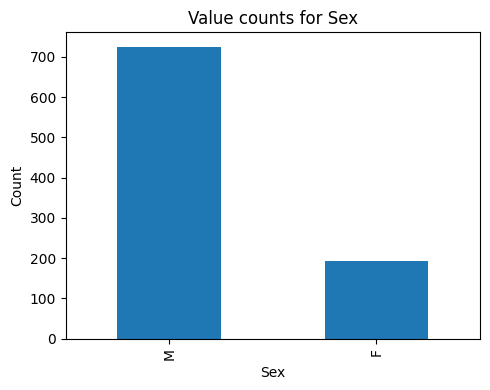

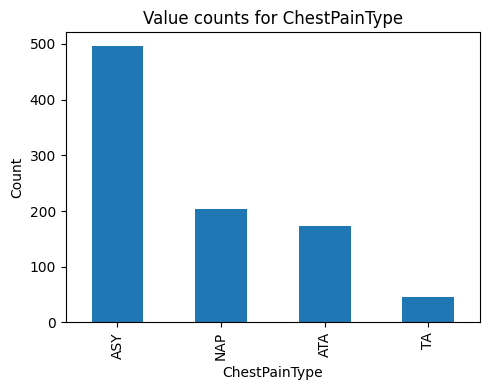

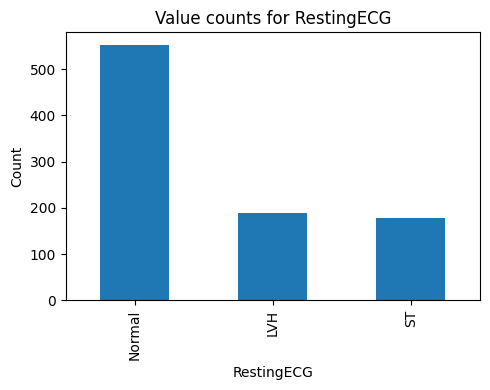

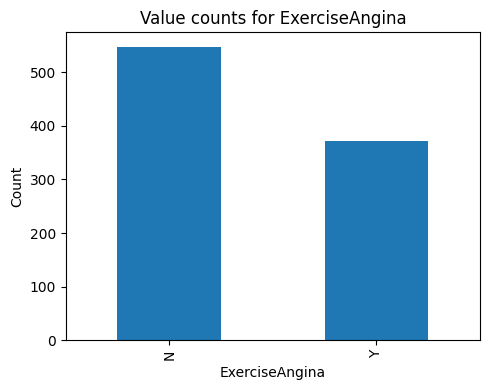

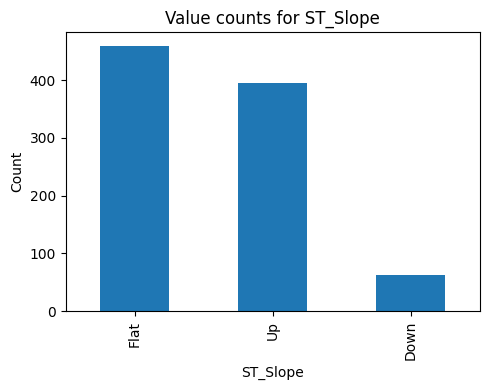

In [ ]:
categorical_cols=[
    "Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"
]

for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

# Encoding

In [ ]:
# Label Encding for binary categorical colums
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])
df["ExerciseAngina"]=le.fit_transform(df["ExerciseAngina"])

In [ ]:
# OneHot Encoding for nominal categorical colums
cat_cols=["ChestPainType", "RestingECG", "ST_Slope"]

df=pd.get_dummies(
    df,
    columns=cat_cols,
    dtype=int # int না দিলে এটা true/false দিয়ে দিবে
)

In [ ]:
df.head(5)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


# Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler, MinMaxScaler, RobustScaler

In [ ]:
target="HeartDisease"

X= df.drop(columns=[target])
y= df[target]

X_train, X_test, y_train, t_test= train_test_split(X, y, test_size=.25, random_state=42)

# Standard Scaling
scaler_sd= StandardScaler()
X_train_std= scaler_sd.fit_transform(X_train) # শুধু train dataset এর উপরে করব, তাহলে data leak হবে না
X_test_std= scaler_sd.transform(X_test)

# convert scaler arrays back to DataFrame for better visualization with column names
X_train_std_df=pd.DataFrame(X_train_std, columns= X_train.columns, index= X_train.index)

X_train_std_df.head(10)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


In [ ]:
# MinMax Scaling
scaler_mm= MinMaxScaler()
X_train_mm= scaler_mm.fit_transform(X_train) # শুধু train dataset এর উপরে করব, তাহলে data leak হবে না
X_test_mm= scaler_mm.transform(X_test)

# convert scaler arrays back to DataFrame for better visualization with column names
X_train_mm_df=pd.DataFrame(X_train_mm, columns= X_train.columns, index= X_train.index)

X_train_mm_df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# Robust Scaling
scaler_r= RobustScaler()
X_train_r= scaler_r.fit_transform(X_train) # শুধু train dataset এর উপরে করব, তাহলে data leak হবে না
X_test_r= scaler_r.transform(X_test)

# convert scaler arrays back to DataFrame for better visualization with column names
X_train_r_df=pd.DataFrame(X_train_r, columns= X_train.columns, index= X_train.index)

X_train_r_df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.153846,0.0,1.25,1.307479,1.0,0.324324,1.0,1.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
362,0.153846,0.0,1.25,-2.481994,0.0,-1.054054,0.0,-0.375,-1.0,0.0,1.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
869,0.384615,0.0,1.00,-0.132964,1.0,0.513514,0.0,0.625,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0
101,-0.230769,0.0,0.00,-0.498615,0.0,-1.027027,0.0,-0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.0
199,0.230769,-1.0,0.00,0.930748,0.0,-1.081081,0.0,0.250,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
